# Human breast cancer

In [1]:

%load_ext autoreload
%autoreload 2

import os

import squidpy as sq
import scanpy as sc
import numpy as np
from scipy import sparse
import math
import matplotlib.pyplot as plt
import pandas as pd
import anndata
from PIL import Image
import os
import sys
sys.path.append('/home/lixiangyu/zjx/')

import scanpy as sc

from SpaMOMA.SpaMOMA import SpaMOMA



/home/lixiangyu/anaconda3/envs/zjx_escnn/lib/python3.9/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


2026-02-18 19:33:51.119910: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 19:33:51.165175: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-18 19:33:51.165220: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-18 19:33:51.165256: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-18 19:33:51.175197: I tensorflow/core/platform/cpu_feature_g

2026-02-18 19:33:52.555297: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# feature：rna/gene_activity_score/peak/protein/metabolite/img

save_directory = "./SpaMOMA_output/HBC/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="rep1",  # 样本唯一ID
    raw_data_path="./datasets/HBC/rep1.h5ad",  # h5ad文件路径
    feature="rna"  
)
spamoma.add_slice(
    sample_id="rep2_HE",  # 样本唯一ID
    raw_data_path="./datasets/HBC/rep2_HE.png",  # h5ad文件路径
    feature="img"  
)
spamoma.set_reference('rep2_HE')




In [3]:
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['rep1'] to rep2_HE


preprocessing rna features...


------Calculating spatial graph...


The graph contains 1148000 edges, 164000 cells.
7.0000 neighbors per cell on average.


Size of Input:  (164000, 313)


2026-02-18 19:34:58.444077: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-18 19:34:58.451686: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [14:51<00:00,  1.78s/it]

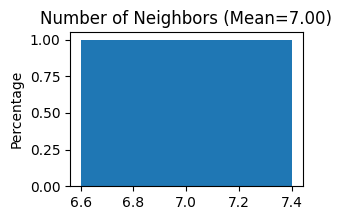

In [4]:
spamoma.preprocess_input_slices({
    'rep2_HE':{
        'downsample':False
    }
})

generating spatial pattern image... gaussian_sigma:0.8, interpolation_method:linear, max_distance_ratio"1.2


saving image...


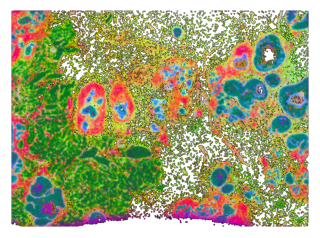

Img for rep1 is saved to /home/lixiangyu/zjx/test_SpaMOMA/SpaMOMA_output/HBC/rep1/RGB.png


Original image saved to: /home/lixiangyu/zjx/test_SpaMOMA/SpaMOMA_output/HBC/rep2_HE/RGB.png


In [5]:
spamoma.generate_imgs({
    'rep1':{
        'gaussian_sigma':0.8,
        'max_distance_ratio':1.2, 
    }
})

In [6]:
spamoma.input_slice_dict

{'rep1': {'sample_id': 'rep1',
  'raw_data_path': './datasets/HBC/rep1.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 164000 × 313
      obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'image_col', 'image_row', 'spot', 'img_x', 'img_y', 'spot_x', 'spot_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'log1p', 'hvg', 'spatial_neighbors', 'moranI'
      obsm: 'he', 'image_coor', 'spatial', 'pca'
      layers: 'raw'
      obsp: 'spatial_connectivities', 'spatial_distances',
  'SPI_path': '/home/lixiangyu/zjx/test_SpaMOMA/SpaMOMA_output/HBC/rep1/RGB.png'},
 'rep2_HE': {'sample_id': 'rep2_HE',
  'raw_data_path': './datasets/HBC/rep2_HE.png',
  'feature': 'img',
  'SPI_path': '/home/

In [ ]:
spamoma.train(parallel_mode=True,coarse_gpu=1,fine_gpu=2)

In [ ]:
spamoma.align_slices()